# Pleque with CUDB

Correct version of pleque: 
```
module load pleque/sumtraic
```

In [1]:
%pylab notebook 

Populating the interactive namespace from numpy and matplotlib


In [2]:
# WIP: 
import sys
sys.path.insert(0, '/compass/home/kripner/Projects/equilibrium_module')

In [3]:
from pleque.io.compass import cudb

/sw/python2/anaconda3.7/lib/python3.7/site-packages/dask/config.py:168: YAMLLoadWarning: calling yaml.load() without Loader=... is deprecated, as the default Loader is unsafe. Please read https://msg.pyyaml.org/load for full details.
  data = yaml.load(f.read()) or {}
/sw/python2/anaconda3.7/lib/python3.7/site-packages/distributed/config.py:20: YAMLLoadWarning: calling yaml.load() without Loader=... is deprecated, as the default Loader is unsafe. Please read https://msg.pyyaml.org/load for full details.
  defaults = yaml.load(f)


In [4]:
# If the first wall is not specified IBA v3.1 limiter is used. 
eq = cudb(6409, time=1.0)

/sw/python2/anaconda3.7/lib/python3.7/site-packages/xarray/core/nanops.py:159: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis=axis, dtype=dtype)


--- No limiter specified. The IBA v3.1 limiter will be used.
---------------------------------
Equilibrium module initialization
---------------------------------
--- Generate 2D spline ---
--- Looking for critical points ---
--- Recognizing equilibrium type ---
>> X-point plasma found.
--- Looking for LCFS: ---
Relative LCFS error: 7.794142311024554e-11
--- Generate 1D splines ---
--- Mapping midplane to psi_n ---
--- Mapping pressure and f func to psi_n ---


In [16]:
eq.plot_overview()

In [6]:
# Full syntax: 
?cudb

## Specify your own first wall: 

In [7]:
first_wall = np.array([[0.6, -0.6],[1.2, -0.6],[1.2, 0.6],[0.6, 0.6],[0.6, -0.6]])
eq2 = cudb(6409, time=1.0, first_wall=first_wall)

baf
---------------------------------
Equilibrium module initialization
---------------------------------
--- Generate 2D spline ---
--- Looking for critical points ---
--- Recognizing equilibrium type ---
>> X-point plasma found.
--- Looking for LCFS: ---
Relative LCFS error: 7.794142311024554e-11
--- Generate 1D splines ---
--- Mapping midplane to psi_n ---
--- Mapping pressure and f func to psi_n ---


<IPython.core.display.Javascript object>


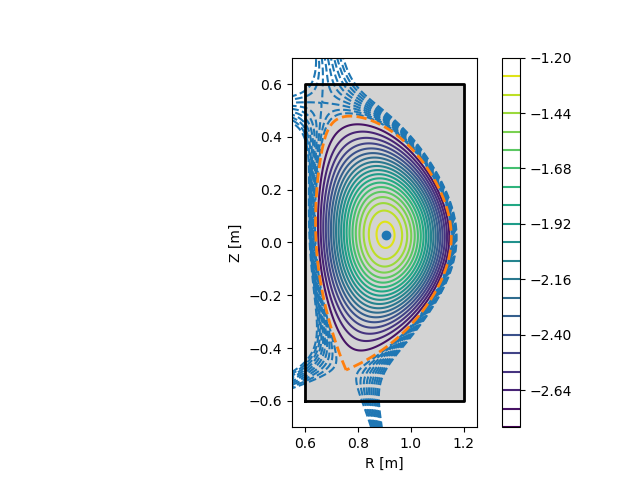

In [17]:
plt.figure()
eq2.plot_overview()

<IPython.core.display.Javascript object>


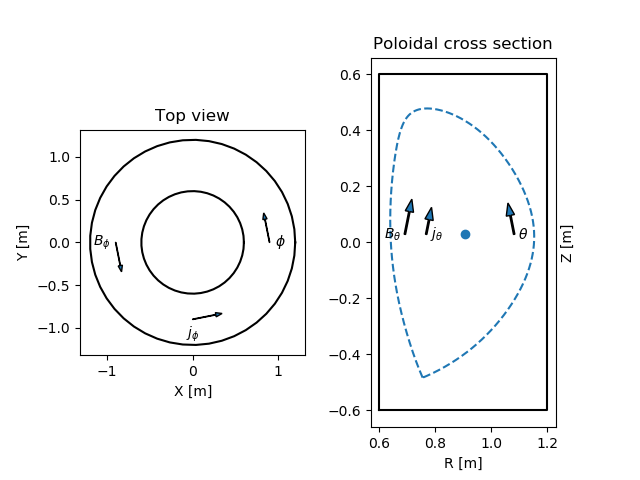

<IPython.core.display.Javascript object>


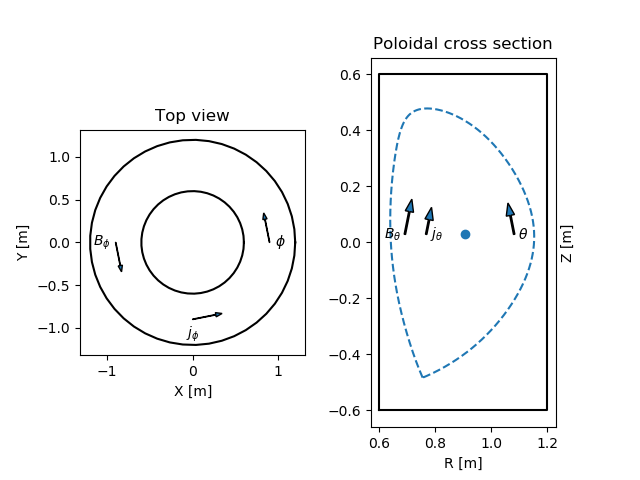

In [18]:
# You can see, there is wrong geometry in the database at the moment: 
eq2.plot_geometry()

In [23]:
# Coordinates instance of first wall: 
fw = eq.first_wall

# Midplane separatrix-lcfs distance: 
r_mid = eq.r_mid(psi_n = 1, grid=False)
mapped_clearance = fw.r_mid - r_mid


<IPython.core.display.Javascript object>


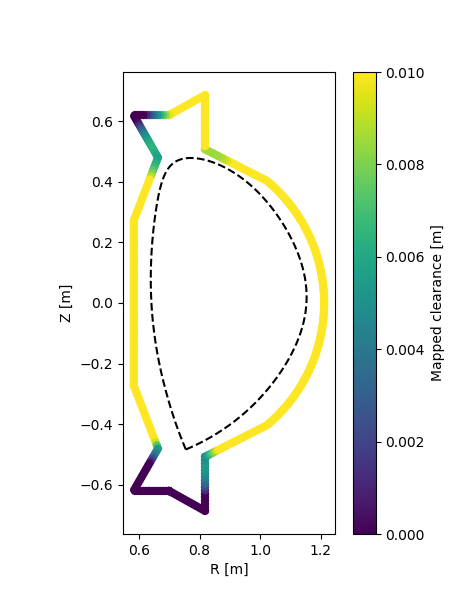

Text(0.5, 0, 'R [m]')

In [25]:
opts = {'vmin': 0, 'vmax': 0.01, 'edgecolors': 'none'}

#ax = axs[0]
figure(figsize=(4.5,6))
ax = gca()

# plot LCFS: 
eq.lcfs.plot(color='k', ls='--')
cl = ax.scatter(fw.R, fw.Z, c=mapped_clearance, **opts)
im = colorbar(mappable=cl, ax=ax, label='Mapped clearance [m]')
ax.set_aspect('equal')
ax.set_ylabel('Z [m]')
ax.set_xlabel('R [m]')



## Magnetic field on the FW: 

In [35]:
B_wall = eq.B_abs(fw)


<IPython.core.display.Javascript object>


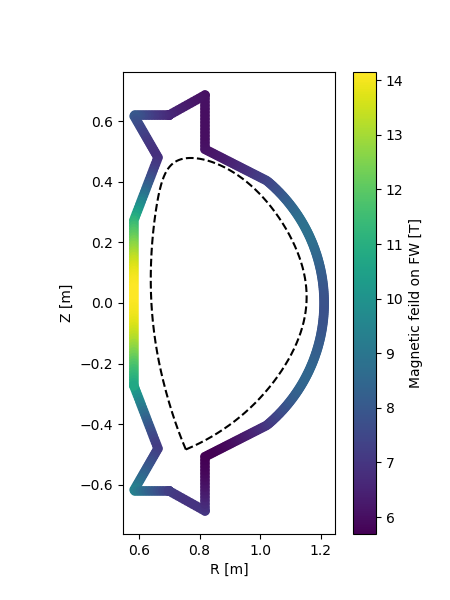

Text(0.5, 0, 'R [m]')

In [33]:
figure(figsize=(4.5,6))
ax = gca()

# plot LCFS: 
eq.lcfs.plot(color='k', ls='--')
# opts = {'vmin': 6.0, 'vmax': 10.0, 'edgecolors': 'none'}
cl = ax.scatter(fw.R, fw.Z, c=B_wall)
im = colorbar(mappable=cl, ax=ax, label='Magnetic feild on FW [T]')
ax.set_aspect('equal')
ax.set_ylabel('Z [m]')
ax.set_xlabel('R [m]')